In [ ]:
''' Descriptive Statistics - Measures of Central Tendency and variability 
Perform the following operations on any open source dataset (e.g., data.csv) 
1. Provide summary statistics (mean, median, minimum, maximum, standard deviation) for 
a dataset (age, income etc.) with numeric variables grouped by one of the qualitative 
(categorical) variable. For example, if your categorical variable is age groups and 
quantitative variable is income, then provide summary statistics of income grouped by the 
age groups. Create a list that contains a numeric value for each response to the categorical 
variable.  
2. Write a Python program to display some basic statistical details like percentile, mean, 
standard deviation etc. of the species of ‘Iris-setosa’, ‘Iris-versicolor’ and ‘Iris-versicolor’ 
of iris.csv dataset. 
 
 Provide the codes with outputs and explain everything that you do in this step.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris_data = load_iris()
iris = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris['species'] = iris_data.target_names[iris_data.target]

print("Iris dataset loaded successfully.")
display(iris.head())

Iris dataset loaded successfully.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# 1. Create a synthetic census dataset
data = {
    'Age Group': np.random.choice(['18-25', '26-35', '36-45', '46-55', '56+'], size=200),
    'Income': np.random.randint(20000, 150000, size=200)
}
df = pd.DataFrame(data)

# 2. Group by 'Age Group' and calculate summary statistics
summary_stats = df.groupby('Age Group')['Income'].agg(['mean', 'median', 'min', 'max', 'std'])

# 3. Print the summary statistics table
print("Summary Statistics for Income by Age Group:")
print(summary_stats)

# 4. Extract list of income values for each age group for future visualization
income_by_age_group = df.groupby('Age Group')['Income'].apply(list).to_dict()

Summary Statistics for Income by Age Group:
                   mean    median    min     max           std
Age Group                                                     
18-25      86489.783784   84058.0  32016  143330  37441.519881
26-35      91717.911111  112633.0  20554  147693  44082.810941
36-45      74982.400000   62468.0  22684  140553  39497.779882
46-55      77159.186047   81715.0  22128  144709  38965.584762
56+        80203.460000   71909.0  22631  144194  35885.052359


In [4]:
# 1. Group the iris DataFrame by species
# 2. Select numeric columns and apply describe to get mean, std, and percentiles
iris_detailed_stats = iris.groupby('species').describe()

# 3. Display the resulting summary table
print("Full Descriptive Statistics for All Iris Features by Species:")
display(iris_detailed_stats)

Full Descriptive Statistics for All Iris Features by Species:


sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

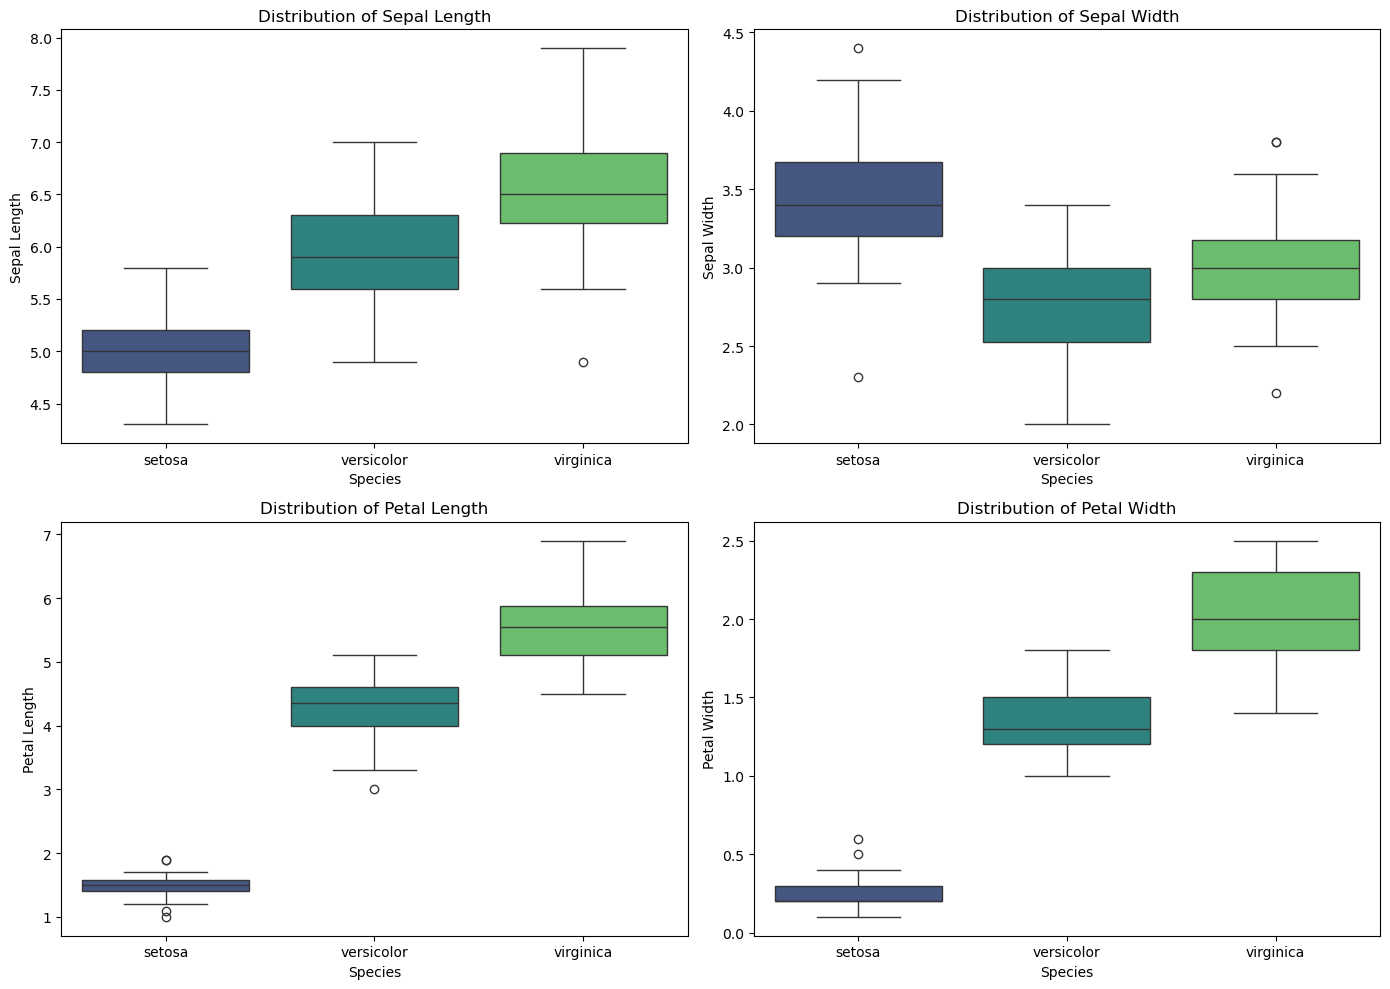

In [5]:
# 1. Initialize a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

# 2. Define the list of numeric features, matching actual DataFrame column names
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# 3. Iterate through features and axes to create boxplots
for i, feature in enumerate(features):
    sns.boxplot(ax=axes_flat[i], x='species', y=feature, data=iris, hue='species', palette='viridis', legend=False)

    # 4. Set descriptive titles and labels
    # Clean up feature name for display, e.g., 'sepal length (cm)' -> 'Sepal Length'
    display_feature_name = feature.replace(' (cm)', '').replace(' ', ' ').title()
    axes_flat[i].set_title(f'Distribution of {display_feature_name}')
    axes_flat[i].set_xlabel('Species')
    axes_flat[i].set_ylabel(display_feature_name)

# 5. Adjust layout and display
plt.tight_layout()
plt.show()